<a href="https://colab.research.google.com/github/hsmu-jeongeun/health-infomatics/blob/main/05_Pseudonymization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5주차 실습: Pandas를 이용한 가명처리 실습

## 학습 목표
- 개인정보 보호를 위한 가명처리·익명처리의 개념을 이해할 수 있다
- Python/Pandas로 이름 마스킹과 나이 범주화를 구현할 수 있다
- K-익명성(K-anonymity)의 원리를 데이터로 확인할 수 있다

---

## 오늘의 핵심 개념: 진료정보교류와 개인정보 보호

### 데이터 3법 핵심 요약
- **개인정보 보호법:** 개인을 식별할 수 있는 정보의 수집·처리 제한
- **정보통신망법:** 온라인 개인정보 수집 동의 절차
- **신용정보법:** 금융·의료 데이터 결합 규정

### 가명처리 vs 익명처리
| 구분 | 가명처리 | 익명처리 |
|------|---------|--------|
| 재식별 가능성 | 있음 (키 있으면) | 없음 |
| 활용 | 통계, 연구 | 제한 없음 |
| 법적 근거 | 데이터 3법 | 개인정보 X |

### K-익명성(K-Anonymity)이란?
> '30대 여성 고혈압 환자'가 10명 이상이면 특정 개인을 지목하기 어려움. K값이 클수록 프라이버시 보호가 강해질 수 있음

- 데이터에서 어떤 레코드도 최소 K개의 동일한 레코드와 구분되지 않아야 함
- 의료 빅데이터 활용 시 핵심 프라이버시 기술

In [ ]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('라이브러리 로드 완료!')

라이브러리 로드 완료!


## 가상의 환자 데이터 생성

In [ ]:
np.random.seed(42)
n = 200  # 환자 수

# 가상의 한국인 이름 목록
male_names   = ['김민준', '이준서', '박도윤', '최시우', '정주원',
                '강지후', '조건우', '윤우진', '장현서', '임서준']
female_names = ['김서연', '이수아', '박지아', '최하은', '정민서',
                '강예은', '조채원', '윤수빈', '장나은', '임지유']

genders = np.random.choice(['남성', '여성'], n)
names = [np.random.choice(male_names) if g == '남성' else np.random.choice(female_names)
         for g in genders]

df = pd.DataFrame({
    '이름':   names,
    '나이':   np.random.randint(18, 80, n),
    '성별':   genders,
    '혈압':   np.random.randint(100, 180, n),
    '진단명': np.random.choice(['고혈압', '당뇨', '심부전', '폐렴', '골절'], n),
    '주소':   np.random.choice(['서울시 강남구', '서울시 종로구', '부산시 해운대구',
                                '대구시 중구', '인천시 남동구'], n),
    '주민번호_뒷자리': [f'{np.random.randint(1000000,9999999)}' for _ in range(n)]
})

print('원본 데이터 (첫 5행):')
df.head()

원본 데이터 (첫 5행):


,이름,나이,성별,혈압,진단명,주소,주민번호_뒷자리
0,조건우,44,남성,173,골절,서울시 강남구,6984684
1,김서연,59,여성,142,심부전,서울시 종로구,3694287
2,최시우,19,남성,143,골절,인천시 남동구,7511634
3,최시우,43,남성,128,골절,부산시 해운대구,5621056
4,정주원,34,남성,112,골절,대구시 중구,9976973


## Step 1. 직접 식별자 삭제 및 마스킹

- 이름: `***`으로 마스킹
- 주민번호: 완전 삭제
- 주소: 시/구 단위로 일반화

![apply method](https://img1.daumcdn.net/thumb/R800x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FdQiV5l%2FbtrgTEfq0I9%2FAAAAAAAAAAAAAAAAAAAAABryCjJivBFfPk5_uYROHdKPajxPj8ZmtoUkBEJ8LHIk%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1774969199%26allow_ip%3D%26allow_referer%3D%26signature%3D2mQUDBhss6rt2894iJbFEOrtcUw%253D)

In [ ]:
# 가명처리 적용
df_pseudo = df.copy()

# 1) 이름 마스킹 — 첫 글자만 남기고 ***
df_pseudo['이름'] = df_pseudo['이름'].apply(lambda x: x[0] + '***')

# 2) 주민번호 완전 삭제
df_pseudo = df_pseudo.drop(columns=['주민번호_뒷자리'])

# 3) 주소 일반화 — 시/도 단위만 남기기
df_pseudo['주소'] = df_pseudo['주소'].apply(lambda x: x.split('시')[0] + '시')

print('Step 1 완료 — 이름 마스킹, 주민번호 삭제, 주소 일반화')
df_pseudo.head()

Step 1 완료 — 이름 마스킹, 주민번호 삭제, 주소 일반화


,이름,나이,성별,혈압,진단명,주소
0,조***,44,남성,173,골절,서울시
1,김***,59,여성,142,심부전,서울시
2,최***,19,남성,143,골절,인천시
3,최***,43,남성,128,골절,부산시
4,정***,34,남성,112,골절,대구시


## Step 2. 나이 범주화 — K-익명성 적용

> 나이 '52세'를 '50대'로 범주화하면, 동일한 조합을 가진 사람이 많아져 개인 식별이 어려워짐

In [ ]:
# =====================
# 수정해 보세요!
# =====================
bin_size = 10  # 나이 구간 크기 (10년 단위)
# =====================

# 나이를 10년 단위로 범주화
bins   = [0, 20, 30, 40, 50, 60, 70, 80, 100]
labels = ['10대', '20대', '30대', '40대', '50대', '60대', '70대', '80대 이상']

df_pseudo['연령대'] = pd.cut(df_pseudo['나이'], bins=bins, labels=labels, right=False)
df_pseudo = df_pseudo.drop(columns=['나이'])  # 정확한 나이 삭제

print('Step 2 완료 — 나이 → 연령대 범주화')
print()
print('연령대별 환자 수:')
print(df_pseudo['연령대'].value_counts().sort_index())

Step 2 완료 — 나이 → 연령대 범주화

연령대별 환자 수:
연령대
10대        9
20대       25
30대       26
40대       36
50대       32
60대       32
70대       40
80대 이상     0
Name: count, dtype: int64


## Step 3. K-익명성 확인 — 50대 여성 그룹 분석

In [ ]:
# 연령대와 성별 조합별 환자 수 확인
group_counts = df_pseudo.groupby(['연령대', '성별'], observed=True).size().reset_index(name='환자수')
print('연령대 × 성별 그룹별 환자 수:')
print(group_counts)

# 50대 여성 환자 수
mask_50f = (df_pseudo['연령대'] == '50대') & (df_pseudo['성별'] == '여성')
count_50f = mask_50f.sum()
print(f'\n50대 여성 환자 수: {count_50f}명')

연령대 × 성별 그룹별 환자 수:
    연령대  성별  환자수
0   10대  남성    4
1   10대  여성    5
2   20대  남성    9
3   20대  여성   16
4   30대  남성   10
5   30대  여성   16
6   40대  남성   22
7   40대  여성   14
8   50대  남성   20
9   50대  여성   12
10  60대  남성   17
11  60대  여성   15
12  70대  남성   18
13  70대  여성   22

50대 여성 환자 수: 12명


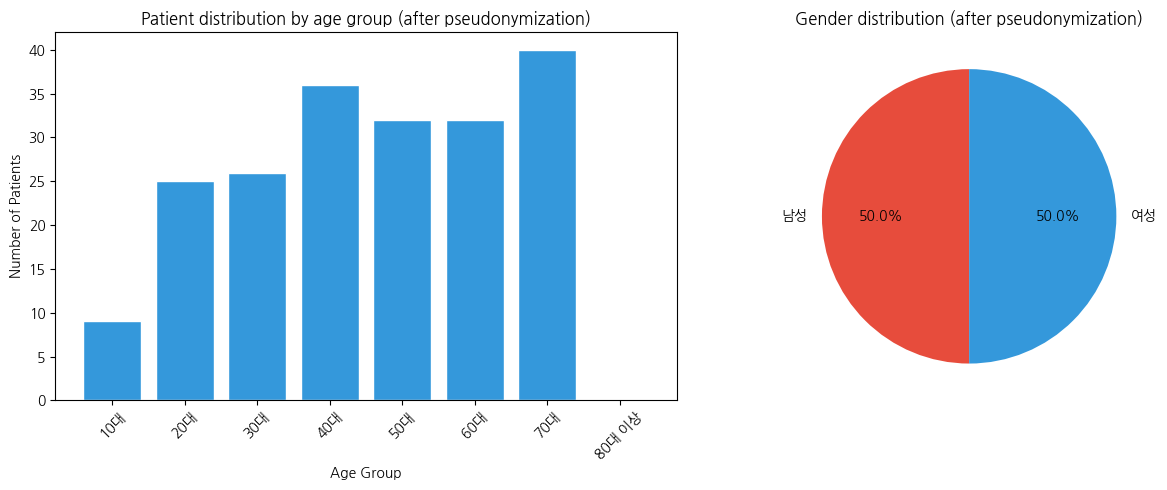

In [ ]:
# 가명처리 후 데이터 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 연령대별 분포
age_counts = df_pseudo['연령대'].value_counts().sort_index()
axes[0].bar(age_counts.index, age_counts.values, color='#3498db', edgecolor='white')
axes[0].set_title('Patient distribution by age group (after pseudonymization)', fontsize=12)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Patients')
axes[0].tick_params(axis='x', rotation=45)

# 성별 분포
gender_counts = df_pseudo['성별'].value_counts()
colors = ['#e74c3c', '#3498db']
axes[1].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Gender distribution (after pseudonymization)', fontsize=12)

plt.tight_layout()
plt.show()

---

## Canvas 퀴즈 안내

아래 코드 셀을 실행하여 나온 **숫자**를 Canvas 퀴즈의 정답으로 제출하세요.

**문제:** K-익명성을 적용해서 나이를 10단위로 범주화 했을 때, '50대'이면서 '여성'인 환자 그룹은 총 몇 명일까요?

In [ ]:
# [실습] 아래 코드를 실행하여 나온 결과를 Canvas 퀴즈의 정답으로 제출
canvas_answer = int(count_50f)
print(f'Answer: {canvas_answer}')